In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [5]:
df = pd.read_csv("customer_data.csv")

In [6]:
df.shape

(7043, 21)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Remove useless column like customerID since it's contains only unique value and model can't find any pattern in it 

In [9]:
df.drop(columns = "customerID", inplace = True)

# Checking null values in data

In [10]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

## using isnull we can only see null values in TotalCharges and we can easily drop them since it's not a big number 

# Finding hidden null values maybe present in category columns to replace them with some meaningfull data

In [11]:
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95]
Churn: ['No' 'Yes']


# Columns where 'No internet service' means feature not present means we can replacw it with same as NO
# Same goes with 'No phone service' in MultipleLines column

In [12]:
no_internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in no_internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

### Now Check again

In [13]:
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13]
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95]
Churn: ['No' 'Yes']


# Detect Outliers for numeric 

In [14]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("columns name :", numeric_cols)
print('--'*40)
for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

columns name : Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
--------------------------------------------------------------------------------
SeniorCitizen             :  16.21% outliers
tenure                    :   0.00% outliers
MonthlyCharges            :   0.00% outliers
TotalCharges              :   0.00% outliers


In [15]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


# Drop rows with missing values in TotalCharges since it only have 11 nulls doesn't effect the data much

In [16]:
df.dropna(subset=['TotalCharges'], inplace=True)

# Unique values for each columns

In [17]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False))
    print("\n" + "-"*50 + "\n")

Column: gender
Unique values: 2
gender
Male      3549
Female    3483
Name: count, dtype: int64

--------------------------------------------------

Column: SeniorCitizen
Unique values: 2
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

--------------------------------------------------

Column: Partner
Unique values: 2
Partner
No     3639
Yes    3393
Name: count, dtype: int64

--------------------------------------------------

Column: Dependents
Unique values: 2
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

--------------------------------------------------

Column: tenure
Unique values: 72
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
38     59
28     57
39     56
44     51
36     50
Name: count, Length: 72, dtype: int64

--------------------------------------------------

Column: PhoneService
Unique values: 2
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

--------------------------------------------------

Column: Mul

# Label Encoding for target variable

In [18]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Convert categorical columns have values(Yes/No) to 0/1

In [19]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# one-hot encoding for columns having (more than 2 categories) and non order data

In [20]:
cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MultipleLines                          7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  Streaming

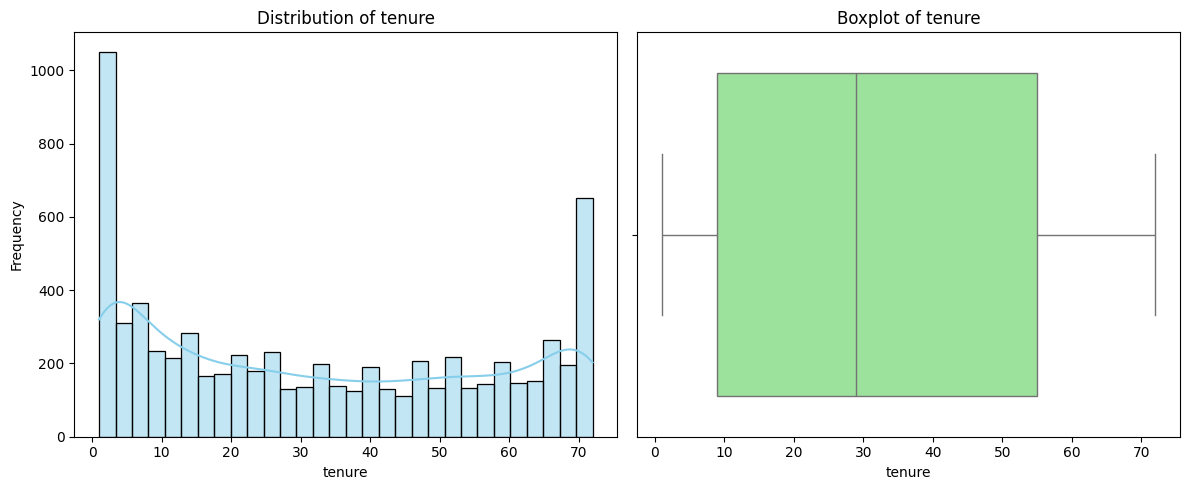

In [22]:
col = 'tenure'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

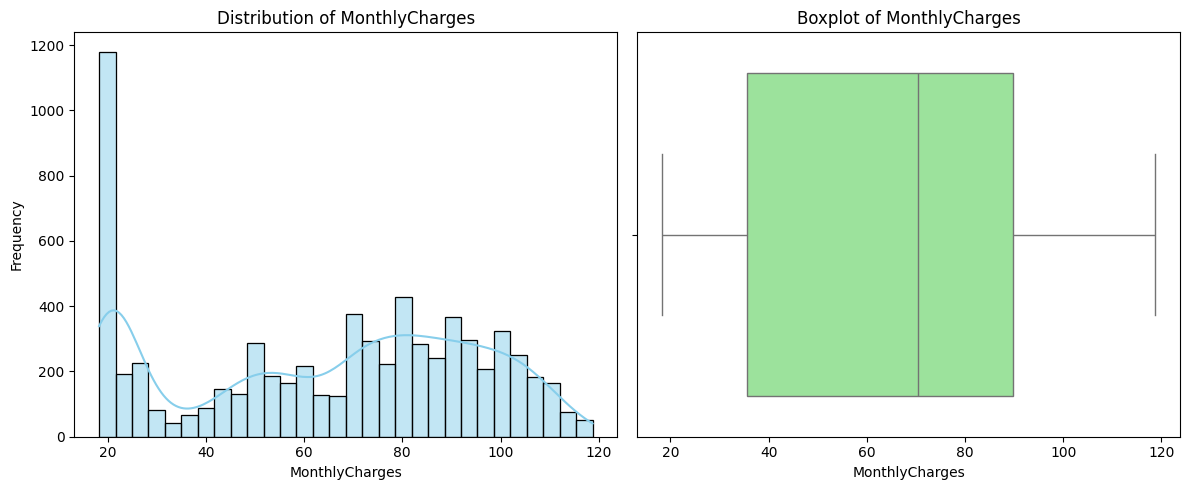

In [23]:
col = 'MonthlyCharges'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

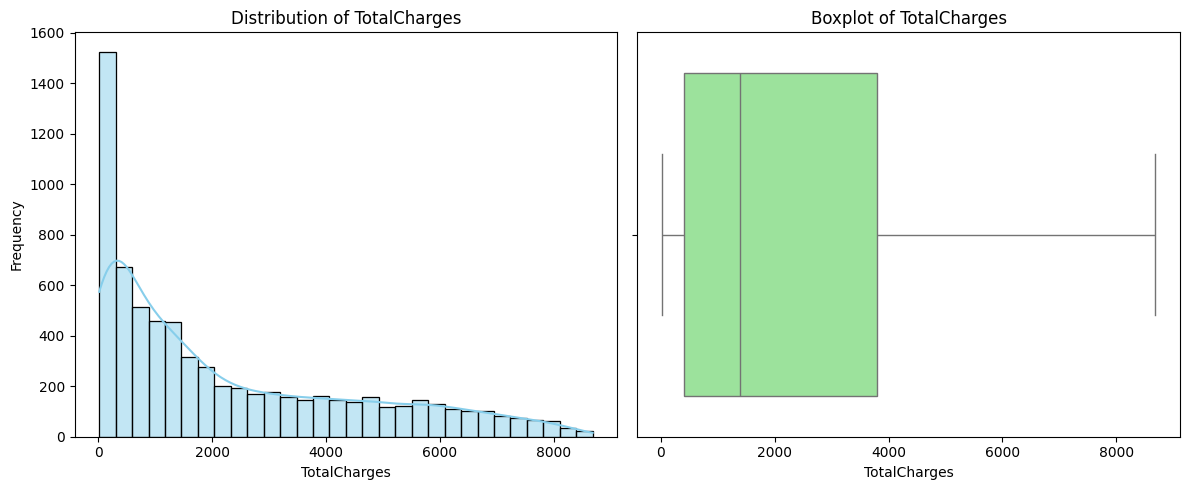

In [24]:
col = 'TotalCharges'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Everything looks fine in box-plot no outliers there 
# also there are quite big values that can be normalized with standard scale method later after splitting the data

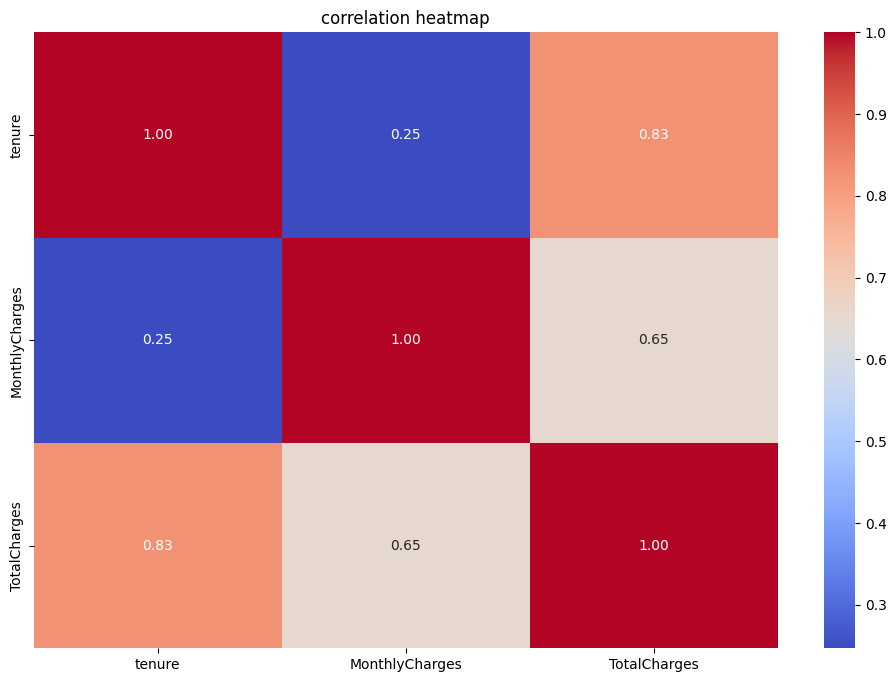

In [25]:
col = ['tenure','MonthlyCharges','TotalCharges']
corr = df[col].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt=".2f")
plt.title("correlation heatmap")
plt.show()

# Tenure and TotalCharges show a strong positive correlation.
# This means — as tenure increases, the total charges also tend to increase.
# The relationship indicates that customers staying longer with the company usually have higher total charges accumulated over time.

# churn distribution

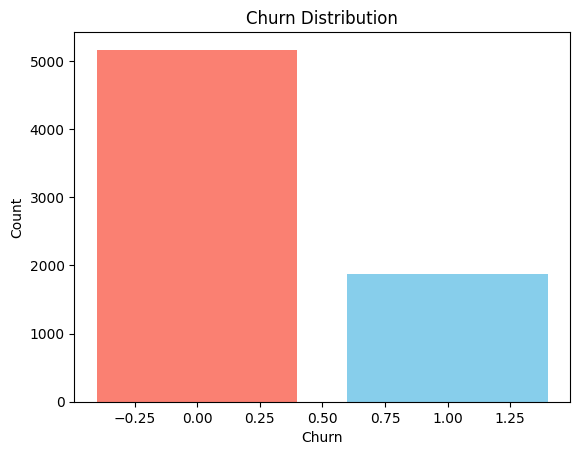

In [26]:
counts = df['Churn'].value_counts()

plt.bar(counts.index, counts.values, color=['salmon','skyblue'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Distribution')

plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MultipleLines                          7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  Streaming

# make variables for model train

In [45]:
x = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into train and test data

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Standard Scale for numeric columns

In [48]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

# Train the model

In [49]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Predict value using logistick regression and evaluation of model performance

In [51]:
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8031
Precision: 0.6483
Recall: 0.5668
F1 Score: 0.6049


# Creating a DataFrame of coefficients for all features 
# checking which features affect customer churn the most

In [54]:
coeff = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

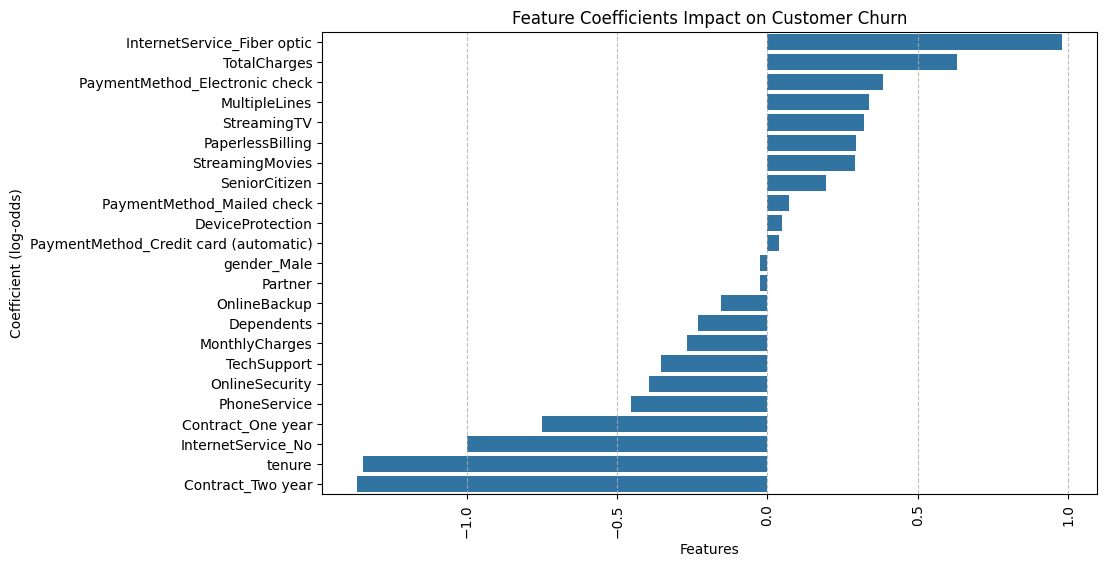

In [55]:
plt.figure(figsize=(10,6))
sns.barplot(
    x = 'Coefficient', 
    y = 'Feature', 
    data = coeff.sort_values(by='Coefficient', ascending = False))
plt.title("Feature Coefficients Impact on Customer Churn")
plt.ylabel("Coefficient (log-odds)")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.grid(True, axis='x', linestyle='--', alpha=0.8)
plt.show()

# According to the chart above, we can clearly see the most effective features that affect customer churn are:
### - `InternetService_Fiber optic` and `TotalCharges`, followed by
### - `PaymentMethod_Electronic check` and `MultipleLines`, and so on.

## That means:
### - More customers tend to churn if they have `InternetService_Fiber optic` and higher `TotalCharges`.

## Features with negative coefficients (reduce churn probability) include:
### - `Contract` for two years and one year
### - `Tenure`
### - `PhoneService`

## This indicates that customers with these features are less likely to churn.
### Features like `Gender`, `Partner`, and `PaymentMethod` have very little or negligible effect on churn.


# Actionable Insights to Reduce Customer Churn
<span style="font-size:90%">
    
## 1. Improve Internet Service Options
- Customers with `InternetService_Fiber optic` are more likely to churn.
- Suggestion: Offer better service plans, bundle deals, or loyalty discounts for fiber optic users.
## 2. Review Pricing and Charges
- Higher `TotalCharges` is associated with higher churn.
- Suggestion: Introduce flexible payment options, discounts for long-term customers, or clarify billing to reduce churn risk.
## 3. Focus on Payment Methods
- Customers using `PaymentMethod_Electronic check` show higher churn probability.
- Suggestion: Encourage alternative payment methods like auto-pay or digital wallets to improve retention.
## 4. Promote Long-Term Contracts
- Features like `Contract` for one or two years reduce churn.
- Suggestion: Incentivize longer contracts with perks, discounts, or additional services.
## 5. Encourage Add-On Services
- `MultipleLines` and `PhoneService` reduce churn.
- Suggestion: Offer add-on packages or bundled services to keep customers engaged and reduce churn risk.
</span>

# Trying another model: KNN to see if we can achieve a better prediction rate

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7626
Precision: 0.5510
Recall: 0.5775
F1 Score: 0.5640


### Not much better compared to Logistic Regression, which had an accuracy rate of 0.8

# Trying another model: RandomForestClassifier to see if we can achieve a better prediction rate

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7974
Precision: 0.6540
Recall: 0.5053
F1 Score: 0.5701


### Better than KNN but still 0.79, while Logistic Regression had 0.8, meaning Logistic Regression is still quite better than the other models on this dataset